<a href="https://colab.research.google.com/github/ChJazhiel/TEC_CCM_2026/blob/main/2D_Feat_extraction_and_selection_Semana_6_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB: Word2Vec, GloVe y Selección de Características
#
# **Objetivos:**
# 1. Entrenar Word2Vec y una aproximación a GloVe sobre un corpus pequeño.
# 2. Comparar embeddings mediante similitud coseno.
# 3. Aplicar selección de características estadística (correlación, F-test/valor-p).
# 4. Aplicar selección basada en modelos (árbol de decisión).
# 5. Implementar un árbol de decisión desde cero y compararlo
# 6. Realizar una selección de características con un árbol de decisión de Scikit-Learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# ============================================================
# PARTE 1. WORD2VEC Y GLOVE (DEMOSTRATIVA)
# ============================================================


##1.1 Corpus pequeño y controlado
### Usamos frases simples con patrones repetidos para que los embeddings aprendan relaciones.

In [ ]:
corpus_base = [
    "el gato come pescado",
    "la gata come pescado",
    "el perro come carne",
    "el cachorro come carne",
    "el gato duerme en casa",
    "el perro duerme en casa",
    "el gato juega con pelota",
    "el perro juega con pelota",
    "el niño come carne",
    "la niña come pescado",
    "el niño juega con pelota",
    "la niña duerme en casa",
    "la mujer lee un libro",
    "el hombre lee un libro",
    "el niño lee un libro",
    "la niña lee un libro",
    "el gato mira un pajaro",
    "el perro mira un gato",
    "el pajaro vuela sobre casa",
    "el pez nada en agua",
]
corpus = corpus_base * 20   # 400 oraciones
corpus_tokenizado = [s.split() for s in corpus]
print("Nº de oraciones:", len(corpus_tokenizado))
print("Ejemplo:", corpus_tokenizado[np.random.randint(len(corpus_tokenizado))])


Nº de oraciones: 400
Ejemplo: ['el', 'perro', 'come', 'carne']


## 1.2 Entrenamiento Word2Vec (Skip-gram)

In [ ]:
! pip install gensim --quiet
from gensim.models import Word2Vec

w2v = Word2Vec(
    sentences=corpus_tokenizado,
    vector_size=30,
    window=3,
    min_count=1,
    sg=1,           # Skip-gram
    epochs=60,
    seed=42,
)

def similitud_w2v(w1, w2):
    return float(w2v.wv.similarity(w1, w2))

pares = [("gato", "perro"), ("gato", "pescado"), ("perro", "carne"),
         ("niño", "niña"), ("hombre", "mujer"), ("gato", "pelota")]
sims_w2v = [similitud_w2v(a, b) for a, b in pares]

print("Word2Vec — similitudes:")
for (a, b), s in zip(pares, sims_w2v):
    print(f"  {a:8s} ↔ {b:8s} : {s:.4f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 62.4 MB/s eta 0:00:00
Word2Vec — similitudes:
  gato     ↔ perro    : 0.9890
  gato     ↔ pescado  : 0.9056
  perro    ↔ carne    : 0.9501
  niño     ↔ niña     : 0.8036
  hombre   ↔ mujer    : 0.9869
  gato     ↔ pelota   : 0.8599


## 1.3 Aproximación a GloVe: co-ocurrencia + SVD
### GloVe construye una matriz de co-ocurrencia y la factoriza.
### Aquí usamos SVD (una versión muy simplificada del original).

In [ ]:
def matriz_coocurrencia(corpus_tok, ventana=3):
    vocab = sorted({w for s in corpus_tok for w in s})
    idx = {w: i for i, w in enumerate(vocab)}
    V = len(vocab)
    M = np.zeros((V, V))
    for oracion in corpus_tok:
        for i, w in enumerate(oracion):
            for j in range(max(0, i - ventana), min(len(oracion), i + ventana + 1)):
                if i == j:
                    continue
                M[idx[w], idx[oracion[j]]] += 1
    return M, vocab, idx

M, vocab, idx = matriz_coocurrencia(corpus_tokenizado, ventana=3)
U, S, Vt = np.linalg.svd(M, full_matrices=False)

dim = 30
emb_glove = U[:, :dim] * np.sqrt(S[:dim])   # embeddings tipo GloVe
# Normalizamos para usar similitud coseno
emb_glove_norm = emb_glove / (np.linalg.norm(emb_glove, axis=1, keepdims=True) + 1e-12)

def similitud_glove(w1, w2):
    v1 = emb_glove_norm[idx[w1]]
    v2 = emb_glove_norm[idx[w2]]
    return float(np.dot(v1, v2))

sims_glove = [similitud_glove(a, b) for a, b in pares]
print("GloVe (SVD) — similitudes:")
for (a, b), s in zip(pares, sims_glove):
    print(f"  {a:8s} ↔ {b:8s} : {s:.4f}")

GloVe (SVD) — similitudes:
  gato     ↔ perro    : 0.5763
  gato     ↔ pescado  : 0.0036
  perro    ↔ carne    : 0.2527
  niño     ↔ niña     : 0.0392
  hombre   ↔ mujer    : 0.5259
  gato     ↔ pelota   : 0.0593


## 1.4 Grafica Comparativa de similitudes

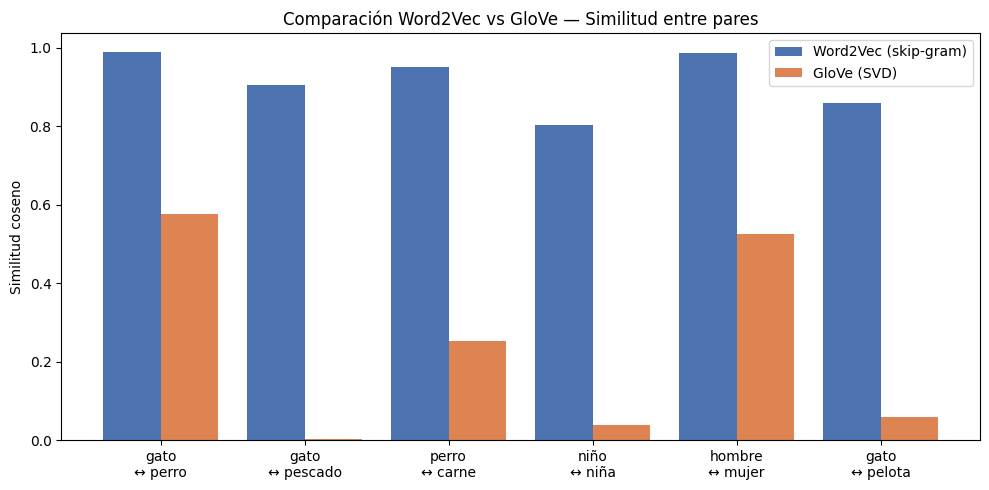

In [ ]:
x = np.arange(len(pares))
ancho = 0.4

plt.figure(figsize=(10, 5))
plt.bar(x - ancho/2, sims_w2v,   ancho, label="Word2Vec (skip-gram)", color="#4C72B0")
plt.bar(x + ancho/2, sims_glove, ancho, label="GloVe (SVD)",          color="#DD8452")
plt.xticks(x, [f"{a}\n↔ {b}" for a, b in pares])
plt.ylabel("Similitud coseno")
plt.title("Comparación Word2Vec vs GloVe — Similitud entre pares")
plt.axhline(0, color="black", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Ejemplo con Word2Vec y GloVe de gensim

In [ ]:
from gensim.models import Word2Vec

# Sample training corpus
sent = [
    "the", "king", "is", "a", "man",
    "the", "queen", "is", "a", "woman",
    "apple", "and", "banana", "are", "fruits"
]
sentences = [sent]

# Train Word2Vec model (using Skip-gram by default if sg=1, or CBOW if sg=0)
# Usamos el corpus tokenizado de la parte anterior
#alternativamente, puedes usar sentences y encontrar la palabra similar a "king"
model_w2v = Word2Vec(sentences, vector_size=30, window=3,epochs=60 , min_count=1, sg=1)

# Encontrar palabras similares
print("Word2Vec similar to 'king':", model_w2v.wv.most_similar("king", topn=3))


Word2Vec similar to 'king': [('are', 0.18748418986797333), ('apple', 0.16054221987724304), ('fruits', 0.15490959584712982)]


In [ ]:
import gensim.downloader as api

# Load a small pre-trained GloVe model (e.g., 25 dimensions from Twitter)
glove_model = api.load("glove-twitter-25")

# Find similar words using global co-occurrence embeddings
print("GloVe similar to 'cat':", glove_model.most_similar("cat", topn=5))


[==================================================] 100.0% 104.8/104.8MB downloaded
GloVe similar to 'cat': [('dog', 0.9590820074081421), ('monkey', 0.920357882976532), ('bear', 0.9143136739730835), ('pet', 0.9108031392097473), ('girl', 0.8880629539489746)]


# =========================================================
# PARTE 2. SELECCIÓN DE CARACTERÍSTICAS
# =========================================================

## 2.1 Dataset: Breast Cancer (30 características)

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
print("Dimensiones:", X.shape, "| Clases:", np.bincount(y))

Dimensiones: (569, 30) | Clases: [212 357]


In [ ]:
correlaciones = X.apply(lambda col: np.corrcoef(col, y)[0, 1])
corr_abs = correlaciones.abs().sort_values(ascending=False)
print("Top 10 por |correlación|:")
print(corr_abs.head(10))

import seaborn as sns

Top 10 por |correlación|:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
dtype: float64


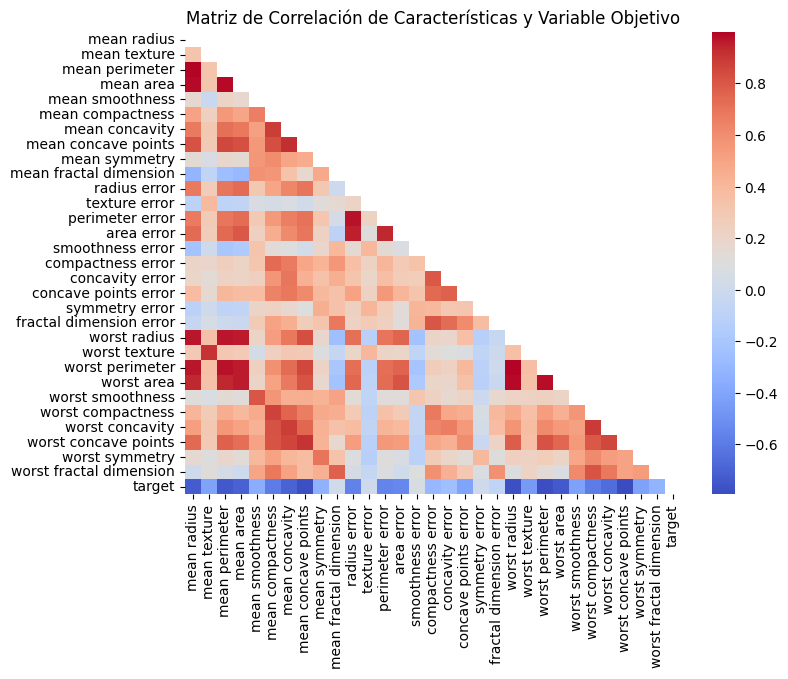

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine X e y en un solo DataFrame to y calcula la matriz de correlación
df_combined = X.copy()
df_combined['target'] = y

# Calcula la matriz de correlacion
corr_matrix = df_combined.corr()

#aplica mascara de triangulacion

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

#Graficar
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Características y Variable Objetivo')
plt.show()

## 2.3 Prueba estadística F (ANOVA) y valor-p.

In [ ]:
from sklearn.feature_selection import f_classif

F_vals, p_vals = f_classif(X, y)
df_estad = pd.DataFrame({
    "feature": X.columns,
    "F": F_vals,
    "p_valor": p_vals,
})
df_estad["significativa"] = df_estad["p_valor"] < 0.05
df_estad = df_estad.sort_values("F", ascending=False)

print("Top 10 por F-statistic:")
print(df_estad.head(10).to_string(index=False))

Top 10 por F-statistic:
             feature          F       p_valor  significativa
worst concave points 964.385393 1.969100e-124           True
     worst perimeter 897.944219 5.771397e-119           True
 mean concave points 861.676020 7.101150e-116           True
        worst radius 860.781707 8.482292e-116           True
      mean perimeter 697.235272 8.436251e-101           True
          worst area 661.600206  2.828848e-97           True
         mean radius 646.981021  8.465941e-96           True
           mean area 573.060747  4.734564e-88           True
      mean concavity 533.793126  9.966556e-84           True
     worst concavity 436.691939  2.464664e-72           True


## 2.4 Selección Basada en Modelo (Arbol de decisión)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tree_sel = DecisionTreeClassifier(random_state=42,max_depth=5)
tree_sel.fit(X_tr, y_tr)

importancias = pd.Series(tree_sel.feature_importances_, index=X.columns)
imp_sorted = importancias.sort_values(ascending=False)

print("Top 10 por importancia en el árbol:")
print(imp_sorted.head(10))


Top 10 por importancia en el árbol:
worst radius            0.714332
worst concave points    0.118831
texture error           0.053907
worst texture           0.031473
worst concavity         0.016712
worst smoothness        0.012978
area error              0.012371
mean texture            0.011536
worst symmetry          0.010987
worst area              0.008652
dtype: float64


## 2.5 Gráfica Comparativa - Top 10 por cada método

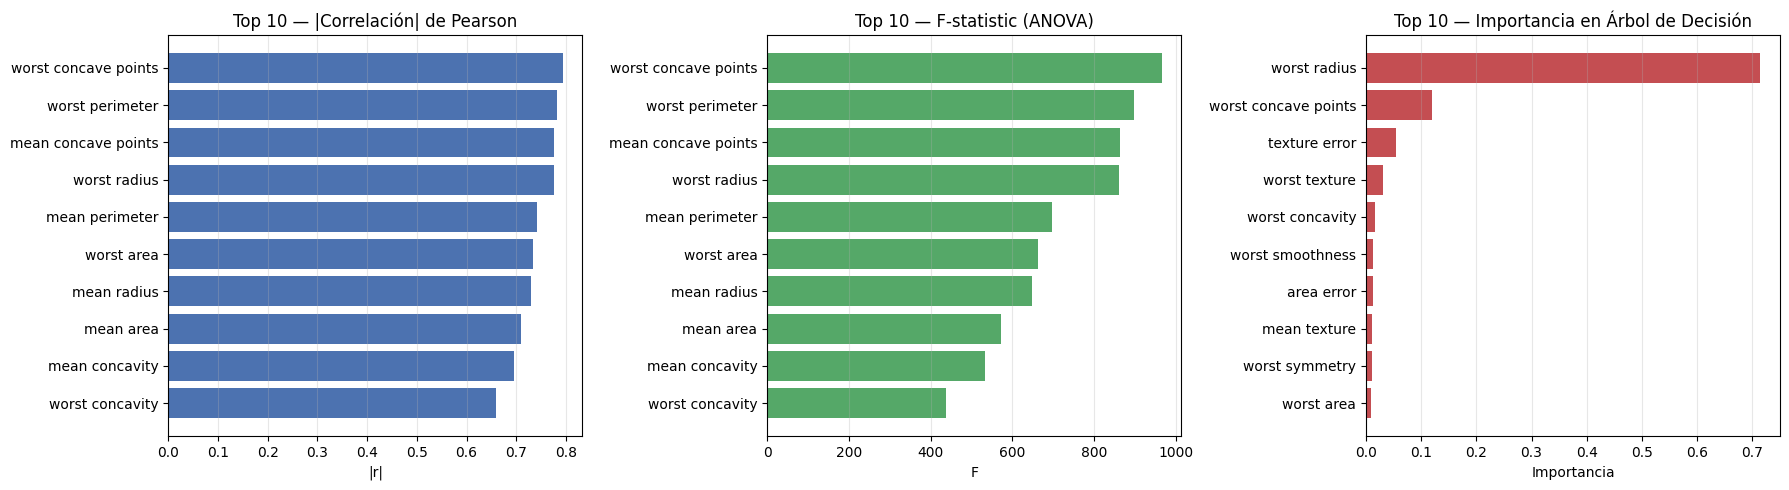

In [ ]:
top_corr  = corr_abs.head(10)
top_f     = df_estad.set_index("feature")["F"].head(10)
# normalizamos F para poder graficar juntos
top_f_norm = top_f / top_f.max()
top_imp   = imp_sorted.head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(top_corr.index[::-1], top_corr.values[::-1], color="#4C72B0")
axes[0].set_title("Top 10 — |Correlación| de Pearson")
axes[0].set_xlabel("|r|")

axes[1].barh(top_f.index[::-1], top_f.values[::-1], color="#55A868")
axes[1].set_title("Top 10 — F-statistic (ANOVA)")
axes[1].set_xlabel("F")

axes[2].barh(top_imp.index[::-1], top_imp.values[::-1], color="#C44E52")
axes[2].set_title("Top 10 — Importancia en Árbol de Decisión")
axes[2].set_xlabel("Importancia")

for ax in axes:
    ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# 🔵 EJERCICIO A — Word Embeddings con un corpus nuevo
##A.1 Corpus de tecnología.

Copia y ejecuta este corpus:

In [ ]:
corpus_tech = [
    "python es un lenguaje de programacion",
    "java es un lenguaje de programacion",
    "python se usa en ciencia de datos",
    "java se usa en aplicaciones empresariales",
    "el programador escribe codigo en python",
    "la programadora escribe codigo en java",
    "el compilador traduce el codigo fuente",
    "el interprete ejecuta el codigo python",
    "la base de datos almacena informacion",
    "el servidor procesa las peticiones",
    "la nube almacena los datos",
    "el algoritmo procesa la informacion",
    "la red conecta los servidores",
    "el usuario interactua con la aplicacion",
    "la interfaz muestra la informacion",
    "el modelo aprende de los datos",
    "la red neuronal procesa imagenes",
    "el clasificador predice la categoria",
    "el regresor predice valores continuos",
    "el dataset contiene ejemplos etiquetados",
]
corpus_tech = corpus_tech * 20   # 400 oraciones
corpus_tok = [s.split() for s in corpus_tech]

## A.2 Entrena dos configuraciones de Word2Vec

In [ ]:
from gensim.models import Word2Vec

# Configuración 1 (similar a la vista en clase)
w2v_A = Word2Vec(corpus_tok, vector_size=30, window=3, sg=1,
                 min_count=1, epochs=60, seed=42)

# Configuración 2 (hiperparámetros CAMBIADOS)
w2v_B = Word2Vec(corpus_tok, vector_size=60, window=5, sg=0,
                 min_count=1, epochs=100, seed=42)


## A.3 Entrena dos configuraciones "GloVe" (SVD)

In [ ]:
import numpy as np

def matriz_coocurrencia(corpus_tok, ventana):
    vocab = sorted({w for s in corpus_tok for w in s})
    idx = {w: i for i, w in enumerate(vocab)}
    M = np.zeros((len(vocab), len(vocab)))
    for oracion in corpus_tok:
        for i, w in enumerate(oracion):
            ini = max(0, i - ventana)
            fin = min(len(oracion), i + ventana + 1)
            for j in range(ini, fin):
                if i != j:
                    M[idx[w], idx[oracion[j]]] += 1
    return M, vocab, idx

def glove_svd(corpus_tok, ventana, dim):
    M, vocab, idx = matriz_coocurrencia(corpus_tok, ventana)
    U, S, _ = np.linalg.svd(M, full_matrices=False)
    emb = U[:, :dim] * np.sqrt(S[:dim])
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    return emb, idx

# Configuración 1
emb_A, idx_A = glove_svd(corpus_tok, ventana=3, dim=30)
# Configuración 2 (CAMBIADA)
emb_B, idx_B = glove_svd(corpus_tok, ventana=5, dim=60)

## A.4 Compara 4 modelos

Usa estos datos y completa la tabla

In [ ]:
pares = [
    ("python", "java"),
    ("programador", "programadora"),
    ("datos", "informacion"),
    ("servidor", "red"),
    ("modelo", "algoritmo"),
    ("python", "datos"),
    ("java", "servidor"),
]

def sim_w2v(modelo, a, b):
    return float(modelo.wv.similarity(a, b)) if a in modelo.wv and b in modelo.wv else float("nan")

def sim_glove(emb, idx, a, b):
    return float(np.dot(emb[idx[a]], emb[idx[b]])) if a in idx and b in idx else float("nan")

print(f"{'Par':<26}{'W2V-A':>10}{'W2V-B':>10}{'GLV-A':>10}{'GLV-B':>10}")
print("-" * 66)
for a, b in pares:
    print(f"{a+' ↔ '+b:<26}"
          f"{sim_w2v(w2v_A,a,b):>10.4f}"
          f"{sim_w2v(w2v_B,a,b):>10.4f}"
          f"{sim_glove(emb_A,idx_A,a,b):>10.4f}"
          f"{sim_glove(emb_B,idx_B,a,b):>10.4f}")

Par                            W2V-A     W2V-B     GLV-A     GLV-B
------------------------------------------------------------------
python ↔ java                 0.8950    0.8425    0.8745    0.3583
programador ↔ programadora    0.9214    0.9206    0.7188    0.3962
datos ↔ informacion           0.7245    0.6356    0.1501    0.2337
servidor ↔ red                0.6205    0.5359    0.0753    0.0377
modelo ↔ algoritmo            0.4345    0.2396    0.0432    0.0069
python ↔ datos                0.4796    0.4001    0.0049    0.2192
java ↔ servidor               0.1359    0.2107   -0.0195   -0.0307


## A.4 Gráfica Comparativa

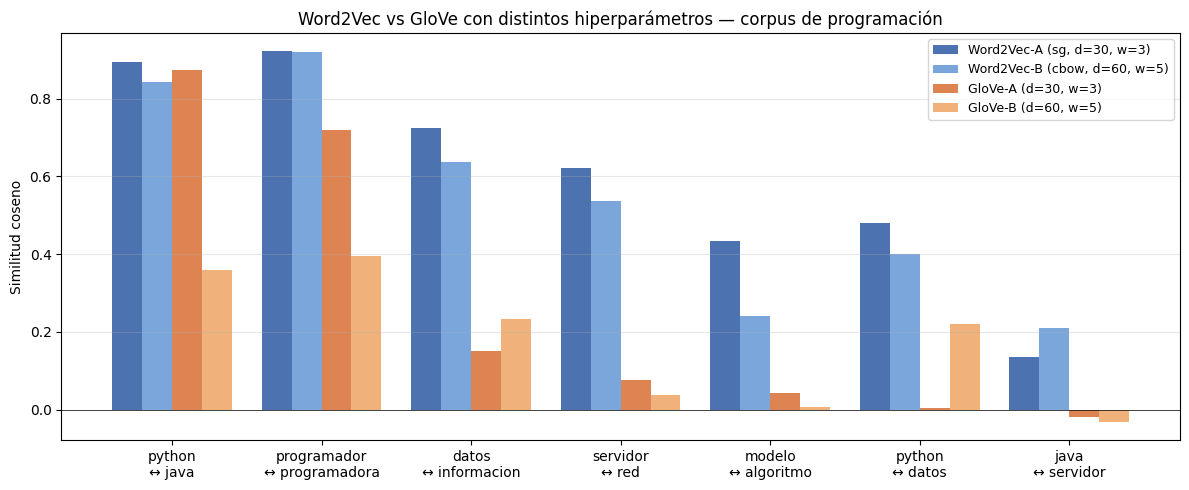

In [ ]:

# Recolecta las cuatro series de similitud para graficar
s_w2vA = [sim_w2v(w2v_A, a, b) for a, b in pares]
s_w2vB = [sim_w2v(w2v_B, a, b) for a, b in pares]
s_glvA = [sim_glove(emb_A, idx_A, a, b) for a, b in pares]
s_glvB = [sim_glove(emb_B, idx_B, a, b) for a, b in pares]

x = np.arange(len(pares))
w = 0.2

plt.figure(figsize=(12, 5))
plt.bar(x - 1.5*w, s_w2vA, w, label="Word2Vec-A (sg, d=30, w=3)", color="#4C72B0")
plt.bar(x - 0.5*w, s_w2vB, w, label="Word2Vec-B (cbow, d=60, w=5)", color="#7AA6DC")
plt.bar(x + 0.5*w, s_glvA, w, label="GloVe-A (d=30, w=3)", color="#DD8452")
plt.bar(x + 1.5*w, s_glvB, w, label="GloVe-B (d=60, w=5)", color="#F0B27A")
plt.xticks(x, [f"{a}\n↔ {b}" for a, b in pares])
plt.ylabel("Similitud coseno")
plt.title("Word2Vec vs GloVe con distintos hiperparámetros — corpus de programación")
plt.axhline(0, color="black", linewidth=0.5)
plt.legend(fontsize=9)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## A.6 ❓ Preguntas del Ejercicio A

- ¿Qué configuración (A o B) da similitudes más altas en promedio? ¿Por qué crees que ocurre?

- ¿Cambia mucho el resultado al pasar de skip-gram a CBOW? Justifica con números.

- En tu opinión, ¿cuál método (Word2Vec o GloVe) captura mejor la relación programador ↔ programadora? ¿Por qué?




# 🟠 EJERCICIO B — Selección de características con un dataset nuevo

## B.1 Genera un dataset de transacciones con tarjeta

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 1500

df = pd.DataFrame({
    "monto":                  np.random.exponential(120, n).round(2),
    "hora":                   np.random.randint(0, 24, n),
    "dia_semana":             np.random.randint(0, 7, n),
    "edad_cliente":           np.random.randint(18, 75, n),
    "ingreso_mensual":        np.random.normal(1800, 600, n).clip(300).round(2),
    "num_transacciones_mes":  np.random.poisson(18, n),
    "distancia_casa_km":      np.random.exponential(6, n).round(2),
    "score_credito":          np.random.randint(300, 850, n),
    "antiguedad_meses":       np.random.randint(1, 240, n),
    "num_reclamos":           np.random.poisson(0.4, n),
    "pais_extranjero":        np.random.binomial(1, 0.15, n),
    "canal_online":           np.random.binomial(1, 0.40, n),
    "monto_medio_historico":  np.random.normal(110, 40, n).clip(10).round(2),
    "ratio_monto_medio":      np.random.gamma(2, 0.5, n).round(3),
})

# Variable objetivo: fraude (1) / no fraude (0)
score = (-3.0
         + 0.020 * df["monto"]
         + 1.5   * df["pais_extranjero"]
         + 0.7   * df["num_reclamos"]
         + 0.9   * df["ratio_monto_medio"]
         - 0.003 * df["score_credito"]
         + 0.05  * df["num_transacciones_mes"]
         - 0.01  * df["antiguedad_meses"]
         + np.random.normal(0, 0.8, n))

prob = 1 / (1 + np.exp(-score))
df["fraude"] = (prob > 0.5).astype(int)

print("Dimensiones:", df.shape)
print("Distribución del target:\n", df["fraude"].value_counts(normalize=True).round(3))

Dimensiones: (1500, 15)
Distribución del target:
 fraude
0    0.714
1    0.286
Name: proportion, dtype: float64


## B.2 Estadísticas F(ANOVA) y valor-p.

In [ ]:
from sklearn.feature_selection import f_classif

X = df.drop(columns="fraude")
y = df["fraude"]

F_vals, p_vals = f_classif(X, y)

res = pd.DataFrame({"feature": X.columns, "F": F_vals, "p_valor": p_vals})
res = res.sort_values("F", ascending=False).reset_index(drop=True)
print(res.to_string(index=False))

              feature           F       p_valor
                monto 1222.384573 2.556936e-196
    ratio_monto_medio   72.382503  4.234157e-17
      pais_extranjero   46.411402  1.384055e-11
         num_reclamos   32.919575  1.160321e-08
     antiguedad_meses   31.047891  2.980340e-08
        score_credito   29.875692  5.388256e-08
num_transacciones_mes    3.758383  5.273100e-02
monto_medio_historico    1.765191  1.841808e-01
                 hora    1.702023  1.922240e-01
    distancia_casa_km    0.566740  4.516756e-01
      ingreso_mensual    0.359813  5.487011e-01
           dia_semana    0.322865  5.699762e-01
         canal_online    0.294544  5.874039e-01
         edad_cliente    0.103031  7.482670e-01


## B.3 Visualiza F y valor-p.

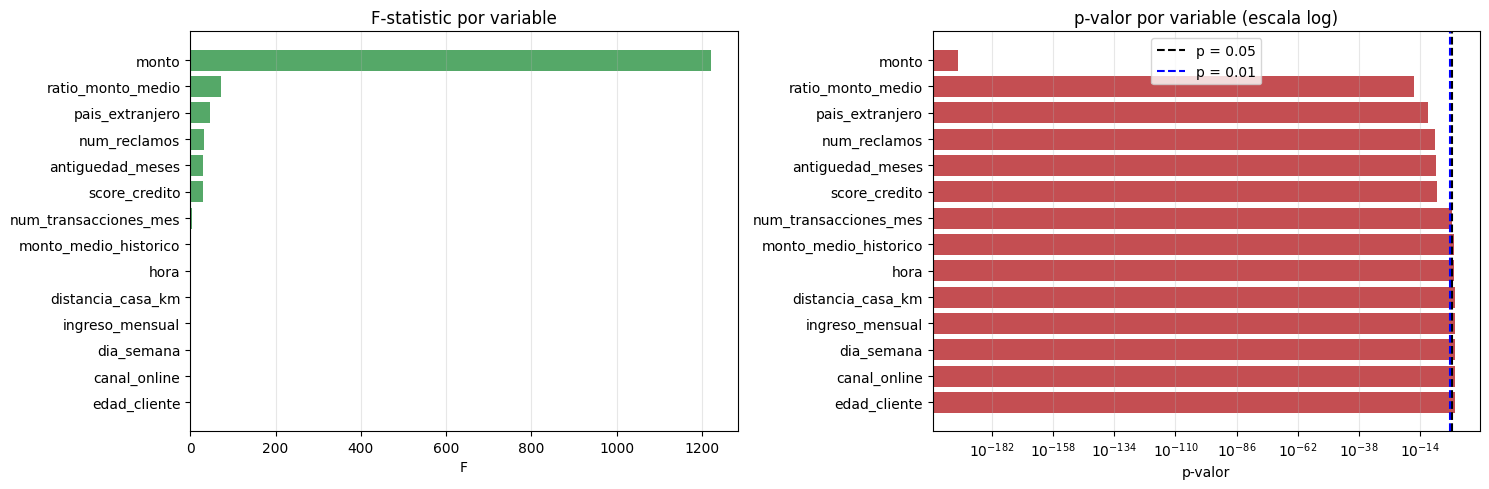

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# F-statistic
axes[0].barh(res["feature"][::-1], res["F"][::-1], color="#55A868")
axes[0].set_title("F-statistic por variable")
axes[0].set_xlabel("F")
axes[0].grid(alpha=0.3, axis="x")

# p-valor (escala log)
axes[1].barh(res["feature"][::-1], res["p_valor"][::-1], color="#C44E52")
axes[1].set_xscale("log")
axes[1].axvline(0.05, color="black", linestyle="--", label="p = 0.05")
axes[1].axvline(0.01, color="blue", linestyle="--", label="p = 0.01")
axes[1].set_title("p-valor por variable (escala log)")
axes[1].set_xlabel("p-valor")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## B.4 Cambia el umbral de p<0.05 a p<0.01

In [ ]:
sel_05 = res[res["p_valor"] < 0.05]
sel_01 = res[res["p_valor"] < 0.01]

print(f"Variables con p < 0.05 : {len(sel_05)}")
print(sorted(sel_05["feature"].tolist()))
print()
print(f"Variables con p < 0.01 : {len(sel_01)}")
print(sorted(sel_01["feature"].tolist()))
print()
print("Variables que se pierden al endurecer el umbral:")
print(sorted(set(sel_05["feature"]) - set(sel_01["feature"])))

Variables con p < 0.05 : 6
['antiguedad_meses', 'monto', 'num_reclamos', 'pais_extranjero', 'ratio_monto_medio', 'score_credito']

Variables con p < 0.01 : 6
['antiguedad_meses', 'monto', 'num_reclamos', 'pais_extranjero', 'ratio_monto_medio', 'score_credito']

Variables que se pierden al endurecer el umbral:
[]


## B.5 Grafico del cambio

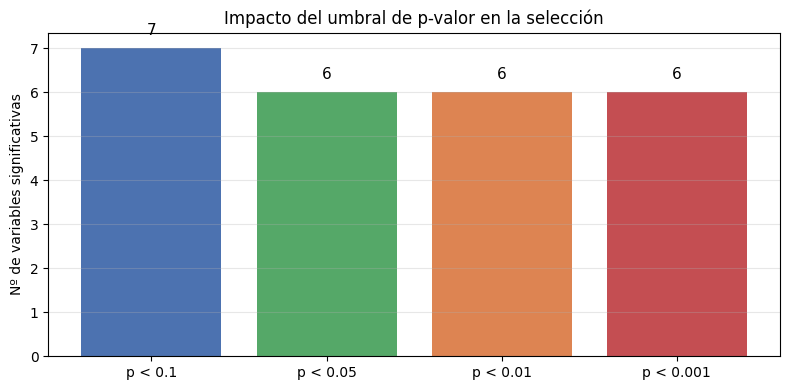

In [ ]:
# Comparativa: cuántas variables sobreviven con cada umbral
umbrales = [0.10, 0.05, 0.01, 0.001]
conteos  = [(res["p_valor"] < u).sum() for u in umbrales]

plt.figure(figsize=(8, 4))
bars = plt.bar([f"p < {u}" for u in umbrales], conteos, color=["#4C72B0","#55A868","#DD8452","#C44E52"])
for b, c in zip(bars, conteos):
    plt.text(b.get_x()+b.get_width()/2, c+0.3, str(c), ha="center", fontsize=11)
plt.ylabel("Nº de variables significativas")
plt.title("Impacto del umbral de p-valor en la selección")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## B.6 ❓ Preguntas del Ejercicio B

- ¿Cuántas variables eran significativas con p < 0.05 y cuántas con p < 0.01?

- ¿Qué variable pierde significancia al endurecer el umbral? ¿Te parece razonable?

- ¿Crees que un umbral más estricto siempre es mejor? Justifica.

- ¿Qué limitación tiene usar solo el p-valor (o solo F) para elegir variables?

#🟢 EJERCICIO C — Árbol con mayor profundidad y criterio entropy
##C.1 Árbol con max_depth=5, criterion="gini" (referencia)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

arbol_ref = DecisionTreeClassifier(max_depth=5, criterion="gini", random_state=42)
arbol_ref.fit(X_tr, y_tr)

imp_ref = pd.Series(arbol_ref.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 — max_depth=5, gini")
print(imp_ref.head(10))

Top 10 — max_depth=5, gini
monto                    0.726848
ratio_monto_medio        0.105726
score_credito            0.074070
antiguedad_meses         0.049761
monto_medio_historico    0.020258
pais_extranjero          0.014840
num_transacciones_mes    0.006380
hora                     0.002118
dia_semana               0.000000
edad_cliente             0.000000
dtype: float64


## C.2 Modificamos el código para aumentar la profundidad y el criterio de selección

In [ ]:
arbol_new = DecisionTreeClassifier(max_depth=8, criterion="entropy", random_state=42) #profundidad 8 y criterio entropía
arbol_new.fit(X_tr, y_tr)

imp_new = pd.Series(arbol_new.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 — max_depth=8, entropy")
print(imp_new.head(10))

# Comparación de accuracy
from sklearn.metrics import accuracy_score
acc_ref = accuracy_score(y_te, arbol_ref.predict(X_te))
acc_new = accuracy_score(y_te, arbol_new.predict(X_te))
print(f"\nAccuracy test  (depth=5, gini)    : {acc_ref:.4f}")
print(f"Accuracy test  (depth=8, entropy) : {acc_new:.4f}")

Top 10 — max_depth=8, entropy
monto                    0.552552
ratio_monto_medio        0.120243
ingreso_mensual          0.075314
antiguedad_meses         0.063001
score_credito            0.059317
num_transacciones_mes    0.039442
pais_extranjero          0.030862
num_reclamos             0.027775
monto_medio_historico    0.015398
dia_semana               0.013510
dtype: float64

Accuracy test  (depth=5, gini)    : 0.8733
Accuracy test  (depth=8, entropy) : 0.8756


## C.3 Gráfico de barras: Top 10 variables más importantes

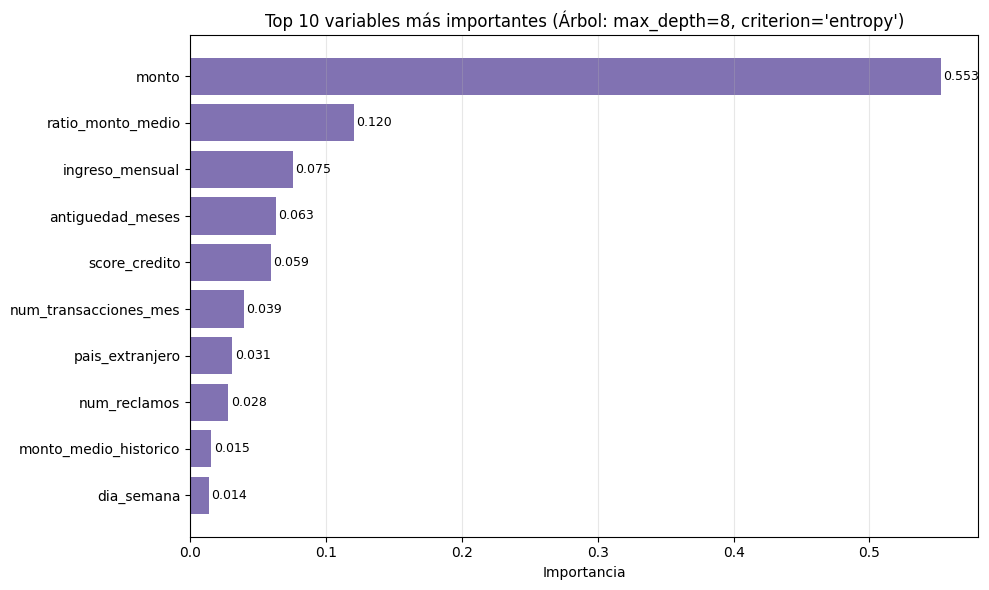

In [ ]:
top10 = imp_new.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10.values, color="#8172B2")
for i, (v, name) in enumerate(zip(top10.values, top10.index)):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
plt.xlabel("Importancia")
plt.title("Top 10 variables más importantes (Árbol: max_depth=8, criterion='entropy')")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## C.4 Comparativa visual

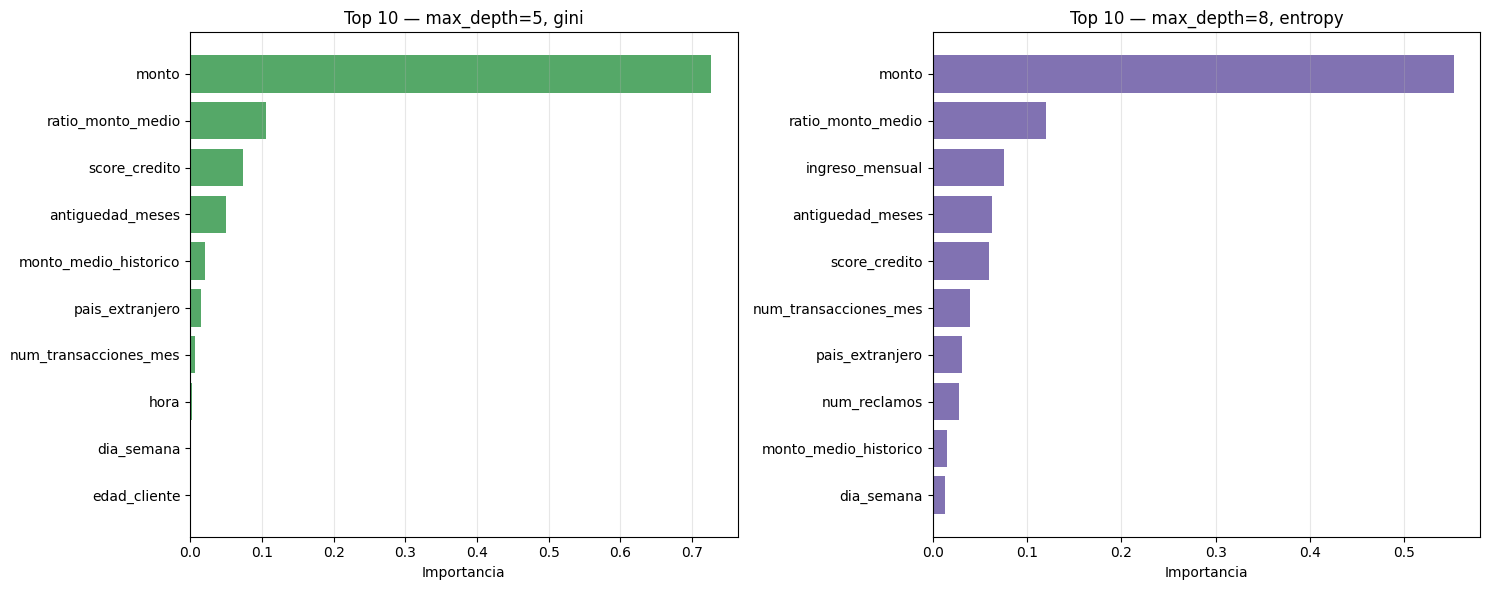

In [ ]:
# Comparación lado a lado de las 10 variables más importantes de cada modelo
top_ref = imp_ref.head(10).sort_values()
top_new = imp_new.head(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top_ref.index, top_ref.values, color="#55A868")
axes[0].set_title("Top 10 — max_depth=5, gini")
axes[0].set_xlabel("Importancia")
axes[0].grid(alpha=0.3, axis="x")

axes[1].barh(top_new.index, top_new.values, color="#8172B2")
axes[1].set_title("Top 10 — max_depth=8, entropy")
axes[1].set_xlabel("Importancia")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# ❓ Preguntas del Ejercicio C

- ¿Cambia el Top 10 de variables al pasar de max_depth=5, gini a max_depth=8, entropy?

- ¿Mejoró, empeoró o se mantuvo la accuracy en test? ¿Por qué crees que ocurre?

- ¿Qué riesgo existe al aumentar la profundidad del árbol? Menciónalo en una frase.

- ¿Coinciden las variables del árbol con las que salieron significativas en el Ejercicio B (F y p-valor)? Comenta al menos dos coincidencias o discrepancias.

# Ejercicio D.

Realiza una selección de variables con un árbol de decisión con los siguientes cambios:

- Profundidades 1, 5, 10, 15, 20.

- Para cada profundidad, prueba ambos criterios de selección (Gini y entropía)

- Usa diferentes números mínimos de observaciones por hoja (min_leaf_size) = 5, 10, 20

- Compara los resultados y determina el mejor conjunto de hiperparámetros posibles para estas combinaciones y selección de las variables.

## Preguntas ejercicio D.

- ¿Qué combinación de hiperparámetros elegiste y por qué?
- ¿Crees que existe alguna relación entre la elección de los hiperparámetros y el resultado de la selección de variables? ¿si?, ¿no? Argumenta tu respuesta
- ¿Crees que un método de selección de variables sea mejor o peor que un método estadístico como el valor-p?